# Generative Classifiers: Naive Bayes

As part of this practical, we will use Naive Bayes to predict if a flight will have a significant delay. We will use a variety of information, including day of the week and flight distance. The dataset will require some pre-processing, but we will focus on the modeling parts more.

Let's import the packages that we will use during the practical:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

## Data processing and exploration

Outline of what we will do as part of data processing:
- load the dataset 
- remove the column `Month`
- in the `CarrierDelay`, `WeatherDelay`, `NASDelay`, `SecurityDelay`, `LateAircraftDelay` columns replace `NaN` with `0`
- extract and remove the column `ArrDelay`
- define the vector `major_delay` as a binary variable

### Loading the dataset

In [18]:
# first load the dataset into a dataframe called data

data = pd.read_csv("data/flights08.csv")
data.head()

,Month,DayofMonth,DayOfWeek,DepTime,CRSDepTime,CRSArrTime,CRSElapsedTime,ArrDelay,DepDelay,Distance,TaxiOut,Cancelled,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,1,3,4,2003.0,1955,2225,150,-14.0,8.0,810,8.0,0,0,NaN,NaN,NaN,NaN,NaN
1,1,3,4,754.0,735,1000,145,2.0,19.0,810,10.0,0,0,NaN,NaN,NaN,NaN,NaN
2,1,3,4,628.0,620,750,90,14.0,8.0,515,17.0,0,0,NaN,NaN,NaN,NaN,NaN
3,1,3,4,926.0,930,1100,90,-6.0,-4.0,515,7.0,0,0,NaN,NaN,NaN,NaN,NaN
4,1,3,4,1829.0,1755,1925,90,34.0,34.0,515,10.0,0,0,2.0,0.0,0.0,0.0,32.0


In [10]:
data=data.drop(columns=["Month"])

data.head()

,DayofMonth,DayOfWeek,DepTime,CRSDepTime,CRSArrTime,CRSElapsedTime,ArrDelay,DepDelay,Distance,TaxiOut,Cancelled,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,3,4,2003.0,1955,2225,150,-14.0,8.0,810,8.0,0,0,NaN,NaN,NaN,NaN,NaN
1,3,4,754.0,735,1000,145,2.0,19.0,810,10.0,0,0,NaN,NaN,NaN,NaN,NaN
2,3,4,628.0,620,750,90,14.0,8.0,515,17.0,0,0,NaN,NaN,NaN,NaN,NaN
3,3,4,926.0,930,1100,90,-6.0,-4.0,515,7.0,0,0,NaN,NaN,NaN,NaN,NaN
4,3,4,1829.0,1755,1925,90,34.0,34.0,515,10.0,0,0,2.0,0.0,0.0,0.0,32.0


In [12]:
data.fillna({
    'CarrierDelay': 0,
    'WeatherDelay': 0,
    'NASDelay': 0,
    'SecurityDelay': 0,
    'LateAircraftDelay': 0
}, inplace=True)

In [15]:
data.drop(columns=['ArrDelay'],inplace=True)

### First look at the data
Have a look at the data:
    
- Do the features make sense?
- What's the shape of the dataset?
- How many missing values are present?
- How many unique values are present per feature? What does that tell you?

In [19]:
print("Features: {}\n".format(list(data.columns)))
print("Shape of the data: {}\n".format(data.shape))
print("Missing values:\n")
print(data.apply(np.isnan).sum())

print("\nNumber of unique values:\n")
print(data.apply(pd.Series.nunique))

Features: ['Month', 'DayofMonth', 'DayOfWeek', 'DepTime', 'CRSDepTime', 'CRSArrTime', 'CRSElapsedTime', 'ArrDelay', 'DepDelay', 'Distance', 'TaxiOut', 'Cancelled', 'Diverted', 'CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay']

Shape of the data: (99999, 18)

Missing values:

Month                    0
DayofMonth               0
DayOfWeek                0
DepTime               1142
CRSDepTime               0
CRSArrTime               0
CRSElapsedTime           0
ArrDelay              1302
DepDelay              1142
Distance                 0
TaxiOut               1142
Cancelled                0
Diverted                 0
CarrierDelay         80370
WeatherDelay         80370
NASDelay             80370
SecurityDelay        80370
LateAircraftDelay    80370
dtype: int64

Number of unique values:

Month                   1
DayofMonth             31
DayOfWeek               7
DepTime              1154
CRSDepTime            213
CRSArrTime            402
CRSElapsed

### Dealing with missing values
The previous step should have shown you two things:
1. Some features have a lot of missing values, in particular those associated with delay at departure (e.g. ``CarrierDelay``). From now on, we will assume that a missing value for delay amounts to no delay.
2. Some features don't have enough unique values to be interesting (which ones?) and should probably removed. 

Based on this we:
- fill the missing values associated with delay by a 0
- remove the feature(s) that don't have enough variability
- remove all remaining rows that have missing values

In [20]:
# Your code here...

for col in ['CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay']:
    data[col].fillna(0, inplace=True)
    
del data['Month']

data.dropna(axis=0, inplace=True)


/var/folders/48/sg6ygl_12s3d3_qq60vknbgr0000gn/T/ipykernel_75112/4110848317.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(0, inplace=True)


### Extracting the response
Our aim is to predict whether there will be a significant delay. The variable that encodes the delay is `ArrDelay`.

1. Start by having a look at ``ArrDelay`` using ``distplot`` from ``seaborn`` .
2. Compute the delay threshold (`delay_threshold`) such that 70% of the positive delays are lower than that threshold. The method `np.percentile` might be useful here.
3. Form a response vector `major_delay` being either 0 or 1 depending on whether the delay is less than or greater or equal to `delay_threshold`.
4. Finally remove the `ArrDelay` column from the dataset.

Percentage higher than threshold? 29.381046349328585pct.


<Figure size 800x600 with 0 Axes>

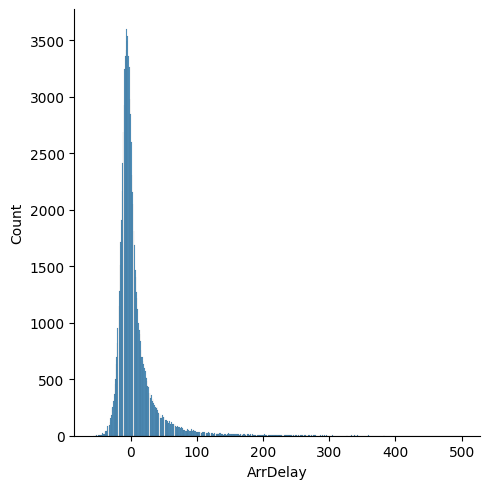

In [21]:
plt.figure(figsize=(8, 6))
sns.displot(data['ArrDelay'])

all_delays = data['ArrDelay']
positive_delays = all_delays[all_delays > 0]
delay_threshold = np.percentile(positive_delays, 70)

print("Percentage higher than threshold? {}pct.".format(
    100 * sum(positive_delays > delay_threshold) / len(positive_delays)))


major_delay = (all_delays >= delay_threshold).astype(int)


Have a look at the value of the delay threshold:

In [ ]:
delay_threshold

## Fit and evaluate a Naive Bayes model

### Train-test split
Next we split the data into training and testing sets.

- Use a random state of ``5175`` for comparable results
- Use 30% of the data for testing
- Stratify the training and testing sets using the `major_delay` vector to have a similar proportion of flights with a major delay in all sets
- Call the new sets `X_train`, `X_test`, `y_train`, `y_test`

In [25]:
from sklearn.model_selection import train_test_split
# Your code here...

X_train, X_test, y_train, y_test = train_test_split(data.drop(columns=['ArrDelay']), major_delay, test_size=0.3, random_state=5175, stratify=major_delay)

### Fit a basic Gaussian Naive Bayes model
Create and fit a Gaussian Naive Bayes model to the training data:

In [26]:
from sklearn.naive_bayes import GaussianNB

# Your code here...

gnb = GaussianNB()

gnb.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


### Make predictions and display the classification report
Make predictions on the test data and have a look at the classification report:

In [27]:
from sklearn.metrics import classification_report

# Your code here...

gnb.predict(X_test)
print(classification_report(y_test, gnb.predict(X_test)))

              precision    recall  f1-score   support

           0       1.00      0.95      0.98     25814
           1       0.76      1.00      0.87      3796

    accuracy                           0.96     29610
   macro avg       0.88      0.98      0.92     29610
weighted avg       0.97      0.96      0.96     29610



### Look at the probabilities
Gaussian Naive Bayes gives probabilities indicating how confident the model is about the classification. Use `distplot` from `seaborn` to display the modeled probabilities for class 1 (major delays).

Use `predict_proba` (not `score`), but you may also want to try `predict_log_proba`. Comment on the resulting graph.

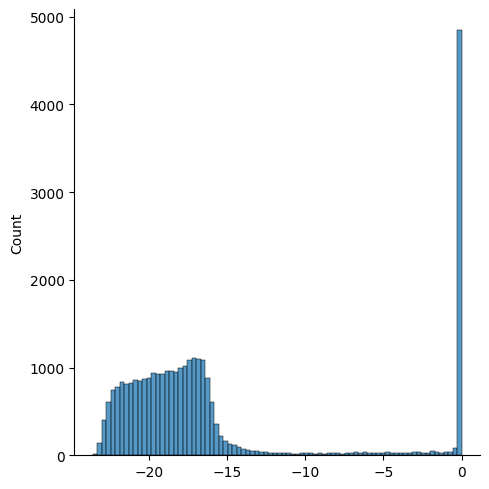

In [28]:
# Your code here...
# Your code here...
log_proba = gnb.predict_log_proba(X_test)

sns.displot(log_proba[:, 1])
plt.show()
